<a href="https://colab.research.google.com/github/jcrodriguesjr0/Machine-Learning-Project-2d-structures/blob/main/Machine_Learning_Project_2d_structures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

arquivo = pd.read_csv('/content/250k_rndm_zinc_drugs_clean_3.csv')
arquivo.head()

,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182


In [ ]:
!pip -q install rdkit-pypi==2021.9.4

In [ ]:
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Include 2D structure of molecules
# https://github.com/rdkit/rdkit/blob/master/rdkit/Chem/PandasTools.py

from rdkit.Chem import PandasTools
PandasTools.AddMoleculeColumnToFrame(arquivo,'smiles', 'Structure')

,smiles,logP,qed,SAS,Structure
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095,
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004,
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633,
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753,
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182,

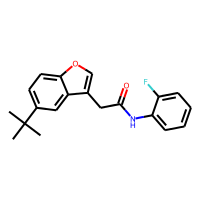
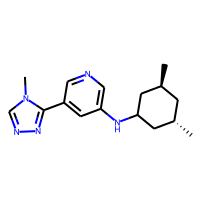
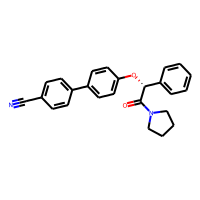
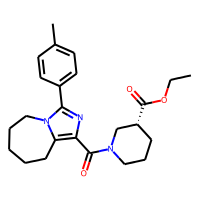
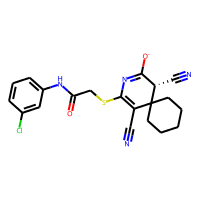

In [ ]:
arquivo.head()

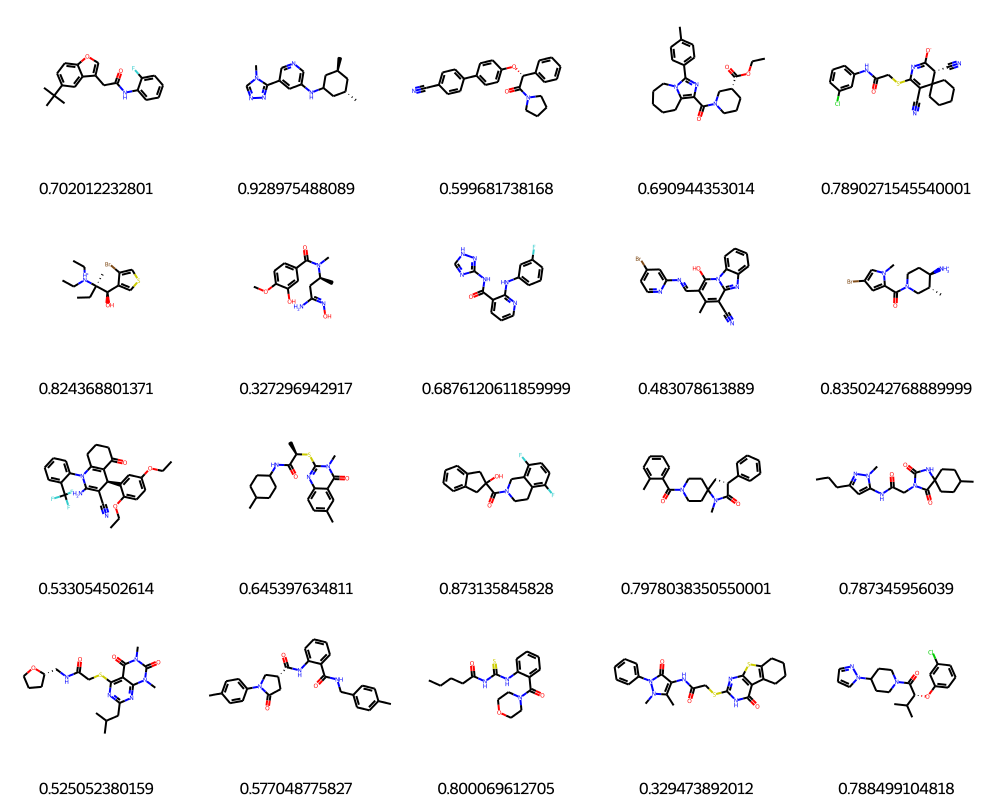

In [ ]:
Draw.MolsToGridImage([x for x in arquivo["Structure"]][:20], maxMols=100,
                     legends=[str(x) for x in arquivo.qed], subImgSize=(200,200), molsPerRow=5)

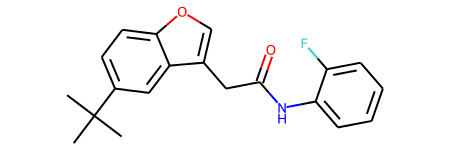

In [ ]:
arquivo.Structure[0]

In [ ]:
# Calculate Atom-Pair fingerprints
from rdkit.Chem import rdMolDescriptors
AP = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(arquivo.Structure[0], nBits=512)
print(np.array(AP))

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1
 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 1 1 0 0 1 1 1 0 1 1 0 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1
 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 1 1 0 0 1 1 1 0 1 0 0
 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0
 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 1 1 0 0 0 0 1
 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0
 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0
 0 1 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0
 1 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 1
 0 0 0 1 1 1 0 0 0 0 0 1 

In [ ]:
# Create a list to store the fingerprints
fingerprints = []

for molecule in arquivo.Structure:
    # Calculate Atom-Pair fingerprints with a specified number of bits (nBits)
    nBits = 512
    AP_fingerprint = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(molecule, nBits=nBits)

    # Store the RDKit fingerprint as a string in the fingerprints list
    fingerprint_string = AP_fingerprint.ToBitString()
    fingerprints.append(fingerprint_string)

# Reshape the fingerprints list into a 2D array
reshaped_fingerprints = [list(fingerprint) for fingerprint in fingerprints]

# Convert the 2D array of fingerprints to a DataFrame
fingerprint_df = pd.DataFrame(reshaped_fingerprints, columns=[f"bit_{i}" for i in range(nBits)])

# Save the DataFrame to a CSV file
csv_filename = "atom_pair_fingerprints.csv"
fingerprint_df.to_csv(csv_filename, index=False)

In [ ]:
fingerprints = pd.read_csv('/content/atom_pair_fingerprints.csv')
fingerprints.head(50)

In [ ]:
# Carregar o DataFrame original a partir do arquivo CSV
csv_filename = "/content/250k_rndm_zinc_drugs_clean_3.csv"
original_df = pd.read_csv(csv_filename)

# Carregar o DataFrame de números binários previamente gerado
binaries_csv_filename = "atom_pair_fingerprints.csv"
fingerprint_df = pd.read_csv(binaries_csv_filename)

# Substituir a coluna 'SMILES' pelo número binário correspondente
original_df["binary"] = fingerprint_df.values.tolist()  # Substitua "bit_0" pelo nome da coluna desejada

# Salvar o DataFrame atualizado em um novo arquivo CSV
updated_csv_filename = "updated_data.csv"
original_df.to_csv(updated_csv_filename, index=False)

In [ ]:
novo = pd.read_csv('/content/updated_data.csv')
novo.head()

,smiles,logP,qed,SAS,binary
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004,"[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, ..."
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633,"[1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, ..."
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182,"[1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, ..."


In [ ]:
y = novo['qed']
print(y)

0         0.702012
1         0.928975
2         0.599682
3         0.690944
4         0.789027
            ...   
249450    0.745901
249451    0.799426
249452    0.878086
249453    0.852917
249454    0.370287
Name: qed, Length: 249455, dtype: float64


In [ ]:
x = novo.drop(['smiles','qed'], axis =1)
print(x)

           logP       SAS                                             binary
0       5.05060  2.084095  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1       3.11370  3.432004  [1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, ...
2       4.96778  2.470633  [1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, ...
3       4.00022  2.822753  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...
4       3.60956  4.035182  [1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, ...
...         ...       ...                                                ...
249450  3.36790  2.900726  [1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, ...
249451  2.87430  2.326627  [1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, ...
249452  2.90054  1.840642  [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...
249453  2.55624  2.024638  [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, ...
249454  3.64990  2.214249  [1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, ...

[249455 rows x 3 columns]


In [ ]:
from sklearn.model_selection import train_test_split

#criando os conjuntos de dados de treino e teste:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.3)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
#Criação do modelo
forest_model = RandomForestRegressor(random_state=1)
forest_model.fit(x_treino, y_treino)
melb_preds = forest_model.predict(val_X)
print(mean_absolute_error(val_y, melb_preds))

ValueError: ignored